# Automatic Plant Disease Detection Using Computer Vision

**COMP9444 25T1 — Project 090**

## 1. Introduction, motivation and problem statement

Plant diseases reduce agricultural productivity and threaten food security.
Expert visual inspection is slow, subjective and does not scale, so the project
brief asks for a CNN that classifies leaves as healthy or diseased and estimates
disease severity, *"to aid farmers and agricultural experts in timely
intervention"*.

That closing phrase is a deployment claim, and it shapes the whole study. We
therefore ask three questions:

| | Question | Brief |
|---|---|---|
| **RQ1** | Can a CNN classify PlantVillage leaves accurately? | Task 1 |
| **RQ2** | Does that accuracy mean the system would work on real field photographs? | implied by the stated aim |
| **RQ3** | Can severity be estimated from image features, and is the estimate trustworthy? | Task 2 |

RQ1 turns out to be easy — and that is precisely why RQ2 matters. The full
hypothesis list and experiment matrix are in [`docs/EXPERIMENTS.md`](../docs/EXPERIMENTS.md);
experiment ids (E1–E26) used below refer to it.

> **How to read and how to re-run this notebook.** Every cell below is stored with
> its output, so the notebook can be read start to finish as a standalone document.
> The heavy work — 20+ training runs — is **not** repeated here: those results are
> loaded from the committed `outputs/*.json` artefacts, which is also what lets any
> number in this notebook be traced back to the run that produced it. Only the cheap
> analyses recompute live.
>
> To execute it yourself you need the repository *and* the datasets, which are too
> large to ship inside a notebook:
>
> ```bash
> git clone https://github.com/Mio812/plant-disease-detection && cd plant-disease-detection
> uv sync
> python -m scripts.prepare_data --dataset both   # PlantVillage + PlantDoc
> jupyter lab notebooks/plant_disease_detection.ipynb
> ```
>
> Reproducing the training runs themselves is `python -m scripts.run_all` (several
> GPU-hours). Cells that need a missing artefact print the exact command that
> produces it instead of failing.


## 2. Setup


In [1]:
import os
import sys
import json
from pathlib import Path

# Locate the project root from wherever the kernel started and make `src` importable.
ROOT = Path.cwd()
while not (ROOT / 'configs' / 'default.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

from src.config import Config
from src.data import class_distribution, parse_class_name, splits_from_config
from src.evaluation import visualize

cfg = Config.load(ROOT / 'configs' / 'default.yaml')
cfg.data.root = str(ROOT / cfg.data.root)
cfg.output_dir = str(ROOT / cfg.output_dir)
OUT = Path(cfg.output_dir)

def load(name):
    """Read a result artefact produced by the pipeline, or None if absent."""
    path = OUT / name
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else None

from IPython.display import Image, display

FIGDIR = ROOT / 'report' / 'figures'
def figure(name):
    """Show a report figure; rebuild the set from outputs/ if it is missing."""
    path = FIGDIR / name
    if not path.exists():
        import subprocess, sys as _s
        subprocess.run([_s.executable, '-m', 'tools.make_figures'], cwd=ROOT, check=False)
    return display(Image(filename=str(path))) if path.exists() else print('missing', name)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('project root:', ROOT)
print('device:', device)


project root: C:\Users\Mio\Documents\9444\plant-disease-detection
device: cuda


## 3. Data sources

**PlantVillage** (Hughes & Salathé, 2015) is the training corpus: 54,305 colour
leaf photographs, 14 crop species, 38 crop/condition classes, captured under
controlled laboratory conditions on uniform backgrounds. The repository also
ships `grayscale` and `segmented` (background-removed) versions of every image,
and we use all three.

**PlantDoc** (Singh et al., 2020, CC BY 4.0) supplies the reality check: ~2,600
in-the-wild photographs scraped from the internet, with cluttered backgrounds and
several leaves per image. We never train on it in the zero-shot experiments — it
is used only to ask whether a PlantVillage model transfers.

Both are fetched by `python -m scripts.prepare_data --dataset both`.


In [2]:
base = ImageFolder(cfg.data.root)
counts = class_distribution(cfg.data.root)
train_idx, val_idx, test_idx = splits_from_config(cfg, base)

print(f'PlantVillage: {len(base):,} images, {len(base.classes)} classes, {len({c.split("___")[0] for c in base.classes})} crops')
print(f'split (seed {cfg.seed}): train {len(train_idx):,} | val {len(val_idx):,} | test {len(test_idx):,}')

variants = [d.name for d in (Path(cfg.data.root).parent).iterdir() if d.is_dir()]
print('PlantVillage variants available:', sorted(variants))
print('PlantDoc test images:', sum(1 for _ in (ROOT / 'data/PlantDoc/test').rglob('*.*'))
      if (ROOT / 'data/PlantDoc/test').exists() else 'not downloaded')


PlantVillage: 54,305 images, 38 classes, 14 crops
split (seed 42): train 37,901 | val 8,189 | test 8,215
PlantVillage variants available: ['color', 'grayscale', 'segmented']
PlantDoc test images: 236


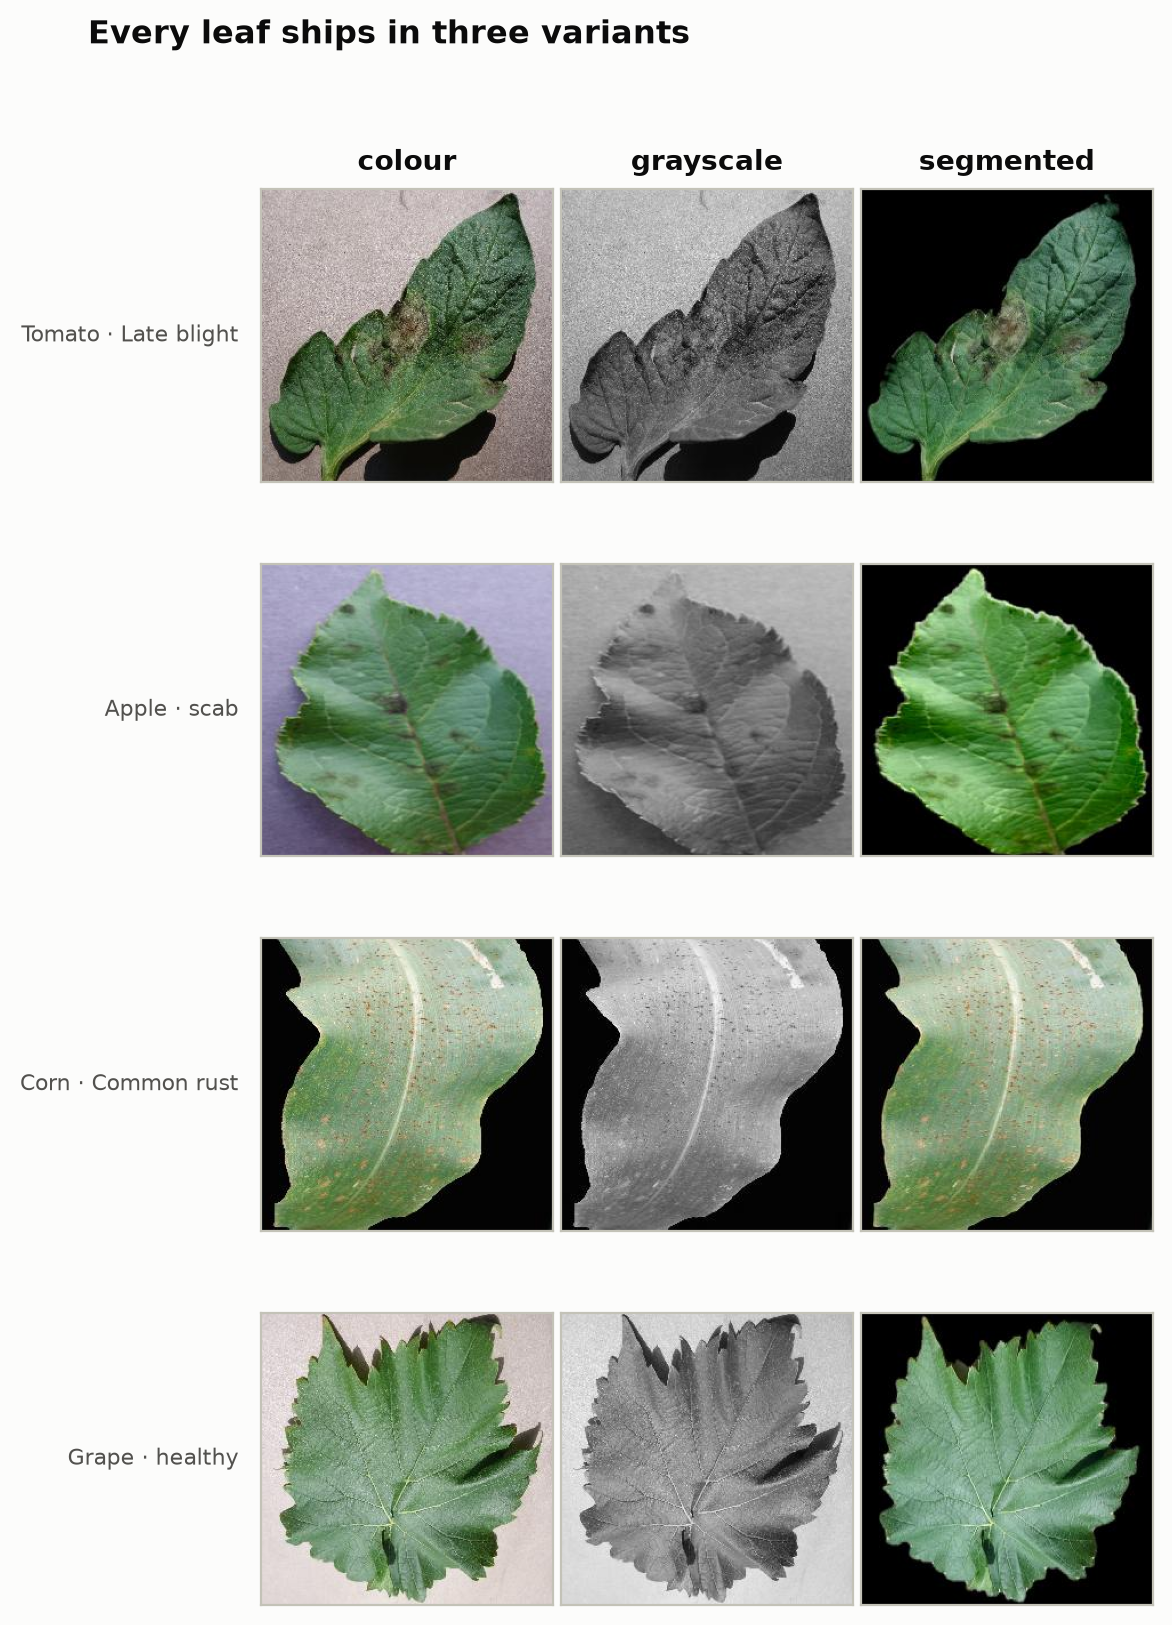

In [3]:
figure('dataset_variants.png')


*The three variants of the same physical leaves. `segmented` is what makes the background experiments in Section 6 possible — and the uniform backdrops visible in the colour column are exactly what the probe in Section 4.2 goes looking for.*


## 4. Exploratory data analysis

Three things matter before modelling: how imbalanced the classes are, how the
healthy/diseased split falls, and — the finding that shaped this project — how
much label information sits in the **background** rather than the leaf.


### 4.1 Class distribution


In [4]:
df = pd.DataFrame(sorted(counts.items(), key=lambda kv: -kv[1]), columns=['class', 'count'])
df['crop'] = df['class'].map(lambda c: parse_class_name(c)[0])
df['status'] = df['class'].map(lambda c: 'healthy' if parse_class_name(c)[2] else 'diseased')

print(f"largest  : {df.iloc[0]['class']} ({df.iloc[0]['count']:,})")
print(f"smallest : {df.iloc[-1]['class']} ({df.iloc[-1]['count']:,})")
print(f"imbalance ratio: {df['count'].max() / df['count'].min():.0f}:1")
df.groupby('status')['count'].agg(['sum', 'count']).rename(columns={'sum': 'images', 'count': 'classes'})


largest  : Orange___Haunglongbing_(Citrus_greening) (5,507)
smallest : Potato___healthy (152)
imbalance ratio: 36:1


,images,classes
status,,
diseased,39221,26
healthy,15084,12


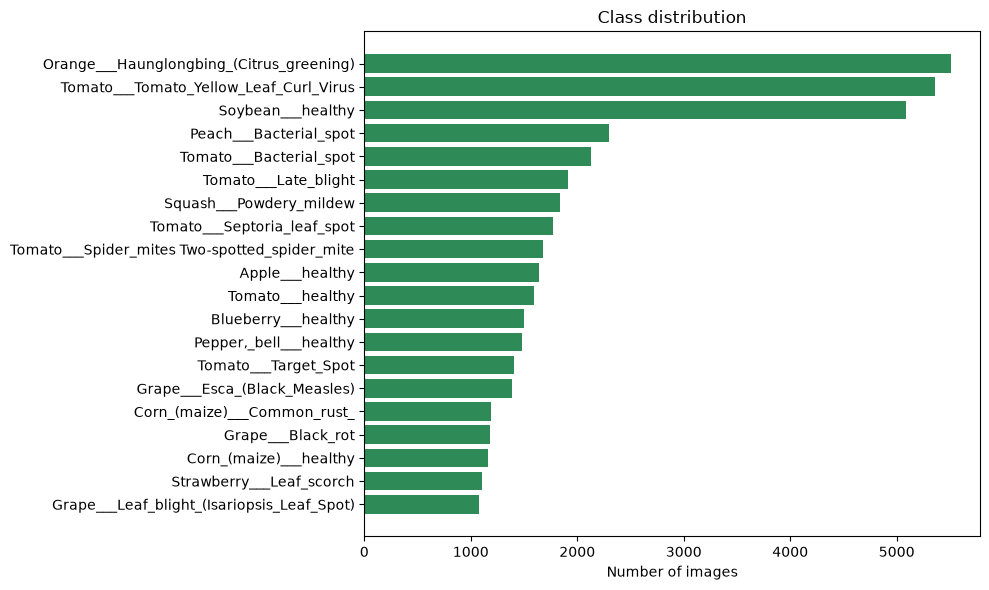

In [5]:
fig = visualize.plot_class_distribution(counts, top=20)
plt.show()


Two consequences for the experimental design:

1. The imbalance is roughly **36:1**, so accuracy alone would be misleading —
   every result below also reports **macro** precision, recall and F1.
2. Only ~28% of images are healthy leaves, so the healthy/diseased decision the
   brief asks for is the easier direction; the fine-grained disease label is the
   hard part.


### 4.2 What is in the background? (E3)

PlantVillage images were captured in sessions, so the backdrop may correlate with
the class. We test this directly: take **8 border pixels** — no leaf at all — and
train a logistic regression on them. If the background carries no label
information the accuracy should sit near chance, 1/38 = 2.6%.


In [6]:
probe = load('bias_probe.json')
if probe:
    print(f"border pixels used : {probe['n_pixels']}")
    print(f"TEST ACCURACY      : {probe['test_accuracy'] * 100:.1f}%")
    print(f"chance             : {probe['chance'] * 100:.1f}%")
    print(f"\n-> {probe['test_accuracy'] / probe['chance']:.0f}x above chance from background alone.")
else:
    print('run: python -m scripts.audit --probe background')


border pixels used : 8
TEST ACCURACY      : 33.7%
chance             : 2.6%

-> 13x above chance from background alone.


This is the pivotal result of the exploratory phase. A classifier that never
sees a leaf still recovers a large share of the label, which means any headline
accuracy on this dataset is partly measuring **capture bias**. Everything in
Section 6 follows from it.


### 4.3 Test-set integrity — leaf grouping

PlantVillage photographs each physical leaf several times. `leaf-map.json`, shipped
with the dataset, records which images share a leaf. A naive random split scatters
those near-duplicates across train and test, so the test score partly rewards
recognising leaves already seen. We measured it: on a random split **74.7% of test
images had a same-leaf twin in training**. We therefore split by *leaf* — every
image of a leaf stays on one side — which removes the leakage (0% by construction)
and is the split used everywhere below.

A perceptual re-check bounds what the map missed (a frozen ImageNet embedding,
calibrated against different-leaf-same-class pairs). It flags ~10.7% of test images,
but the same-leaf and same-class distributions overlap heavily, so this over-counts
PlantVillage's near-identical *distinct* leaves; the true residual is well below it.
The decisive check is that removing the known leakage cost only ~0.3 accuracy
points on the ensemble — structural leakage would have cost far more.


In [7]:
res = load('residual_leakage.json')
if res:
    print(f"random-split leakage (measured earlier): 74.7% of test had a same-leaf twin in train")
    print(f"leaf-grouped split: 0% by construction")
    print(f"residual near-duplicate upper bound: {res['test_flagged_pct']:.1f}% "
          f"(over-counts look-alikes; separation only {res['separation']:.2f} cosine)")


random-split leakage (measured earlier): 74.7% of test had a same-leaf twin in train
leaf-grouped split: 0% by construction
residual near-duplicate upper bound: 10.7% (over-counts look-alikes; separation only 0.11 cosine)


## 5. Models and methods

### 5.1 Three baselines (E1)

Three architectures spanning two families, all trained through one identical
pipeline so the comparison isolates the architecture:

| Model | Family | Rationale |
|---|---|---|
| **Custom CNN** | from scratch | what a small purpose-built network achieves with no external data |
| **ResNet-18** | ImageNet-pretrained | strong residual backbone of moderate size |
| **MobileNet-V2** | ImageNet-pretrained | lightweight, representative of edge deployment |

Training: AdamW (lr 1e-3, weight decay 1e-4), cosine schedule, cross-entropy with
0.1 label smoothing, random resized crop / flip / ±20° rotation / colour jitter,
early stopping on validation accuracy. The backbone weights are the only
pre-existing component; the classifier heads and the pipeline are ours.

### 5.2 Proposed model: validation-tuned soft-voting ensemble (E2)

Our proposed model averages the members' softmax vectors with weights chosen by
grid search **on the validation split**, then applied unchanged to the test split,
so the tuning never sees test data.

### 5.3 Removing the shortcut (E8–E10)

Given the Section 4.2 finding, we retrain with interventions that make the
background uninformative, and compare them under one split:

| Intervention | What it changes | Role |
|---|---|---|
| Strong augmentation, `p=0.0` | heavier augmentation only | **control** — separates augmentation from de-shortcutting |
| Background randomisation `p=0.7` | leaf composited onto a random background | the proposed fix |
| Trained on `segmented` | background removed entirely | also the clean control for E4 |
| Trained on `grayscale` | colour removed | how much of the signal is colour? |

### 5.4 Severity estimation (E12–E14, E25–E26)

PlantVillage has no severity labels, so severity is derived from image features:
the leaf is segmented (Otsu on saturation, or the official mask), lesion pixels are
the leaf pixels outside the healthy-green hue band, and the lesion-area fraction is
bucketed into ordinal grades at [0.005, 0.05, 0.20].

That classical estimator needs a mask at inference time, so it is not yet part of the
network. The delivered model therefore **expands the classifier** as the brief asks: a
second linear head on the shared ResNet-18 backbone regresses √(lesion ratio) through
a sigmoid, trained jointly with the classification objective under a masked MSE loss
(weight 10) so that leaves without a cached ratio contribute only to the classification
term. At inference, one forward pass returns both the class and the severity, and the
grade uses the same rubric bands. E25 is the ablation that motivates joint training: the
same head *probed* on a frozen classification backbone instead of trained with it.


In [8]:
from src.models import build_model

rows = []
for name in ['custom_cnn', 'resnet18', 'mobilenet_v2']:
    model = build_model(name, len(base.classes), pretrained=False)
    total = sum(p.numel() for p in model.parameters())
    rows.append({'model': name, 'parameters': f'{total/1e6:.1f}M'})
pd.DataFrame(rows).set_index('model')


,parameters
model,
custom_cnn,0.4M
resnet18,11.2M
mobilenet_v2,2.3M


## 6. Results

### 6.1 RQ1 — laboratory performance (E1, E2)


Reported on the held-out **leaf-grouped** test split of n = 8,215 images. The
ensemble row is the fixed-weight soft vote `[0.2, 0.5, 0.3]` used for every
headline number in this project (`eval_plantvillage.json`). A separate
validation-tuned search returns `[0.5, 0.15, 0.35]` and 99.54%; the two agree to
0.01 points, and we quote the fixed-weight arm throughout so that the per-disease
and confusion-matrix figures below come from the same model.


In [9]:
lab = load('eval_plantvillage.json')
hist = {m: load(f'{m}_history.json') for m in ['custom_cnn', 'resnet18', 'mobilenet_v2']}
rows = []
for m, h in hist.items():
    if not h: continue
    t = h['test_metrics']
    rows.append({'model': m, 'accuracy': t['accuracy'], 'precision': t['precision_macro'],
                 'recall': t['recall_macro'], 'f1': t['f1_macro']})
if lab:
    rows.append({'model': 'ensemble (0.2/0.5/0.3)', 'accuracy': lab['ensemble'] / 100,
                 'precision': None, 'recall': None, 'f1': None})
pd.DataFrame(rows).set_index('model').round(4) if rows else print('run the pipeline first')


,accuracy,precision,recall,f1
model,,,,
custom_cnn,0.9869,0.9843,0.9821,0.9831
resnet18,0.9933,0.9919,0.9922,0.9919
mobilenet_v2,0.9946,0.9903,0.9926,0.9914
ensemble (0.2/0.5/0.3),0.9953,NaN,NaN,NaN


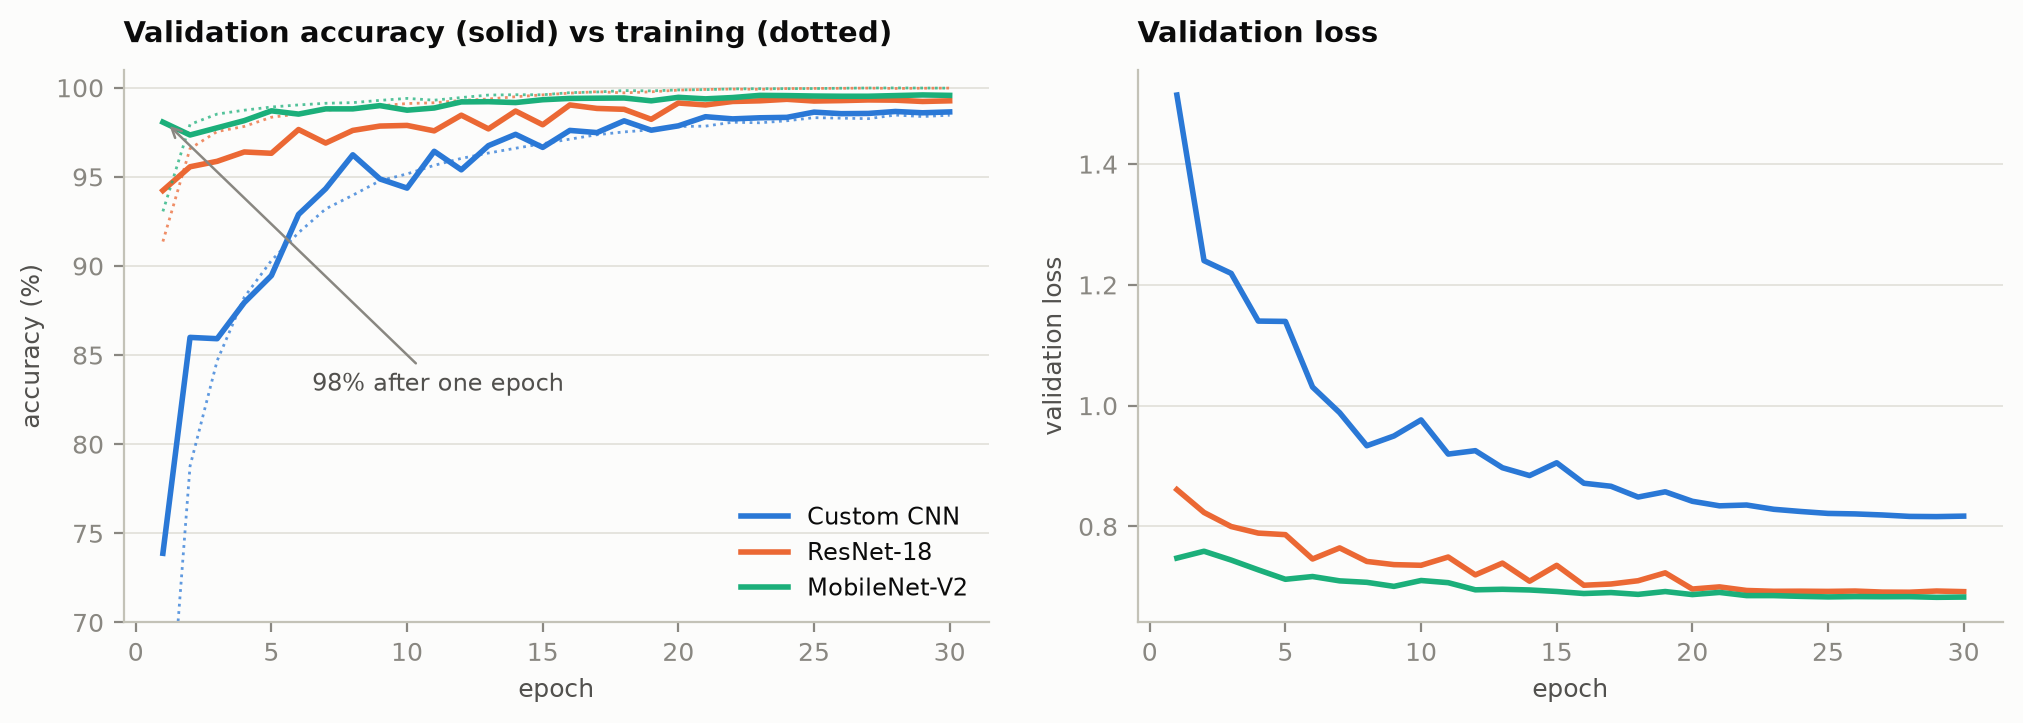

In [10]:
figure('learning_curves.png')


*Training histories. MobileNet-V2 is at 98% validation accuracy after a single epoch and the remaining 29 epochs buy 1.5 points — the benchmark is close to solved before training properly begins. The custom CNN, with no ImageNet initialisation, starts 24 points lower and still converges to 98.6%. Nothing here is overfitting: validation tracks training throughout, which is what makes the field results in Section 6.2 surprising.*


The brief asks for **healthy vs diseased**. Collapsing the 38 classes to two, the
ensemble reaches **99.96%** — not a perfect 100%, because three of its 39 errors do
cross that boundary, and two of those are diseased leaves called healthy, which is
the costlier direction for a farmer:


In [11]:
import itertools
def binary_accuracy(tag, n=8215):
    cp = load(f'{tag}_confused_pairs.json')
    if not cp: return None
    h = lambda x: 'healthy' in x.lower()
    cross = sum(p['count'] for p in cp['pairs'] if h(p['true']) != h(p['pred']))
    return 100 * (n - cross) / n, cp['total_errors'], cross

for tag in ['custom_cnn', 'resnet18', 'mobilenet_v2', 'ensemble_plantvillage']:
    r = binary_accuracy(tag)
    if r:
        print(f'  {tag:14s} 38-class errors {r[1]:3d} | healthy<->diseased crossings {r[2]:2d} | BINARY {r[0]:.2f}%')


  ensemble_plantvillage 38-class errors  39 | healthy<->diseased crossings  3 | BINARY 99.96%


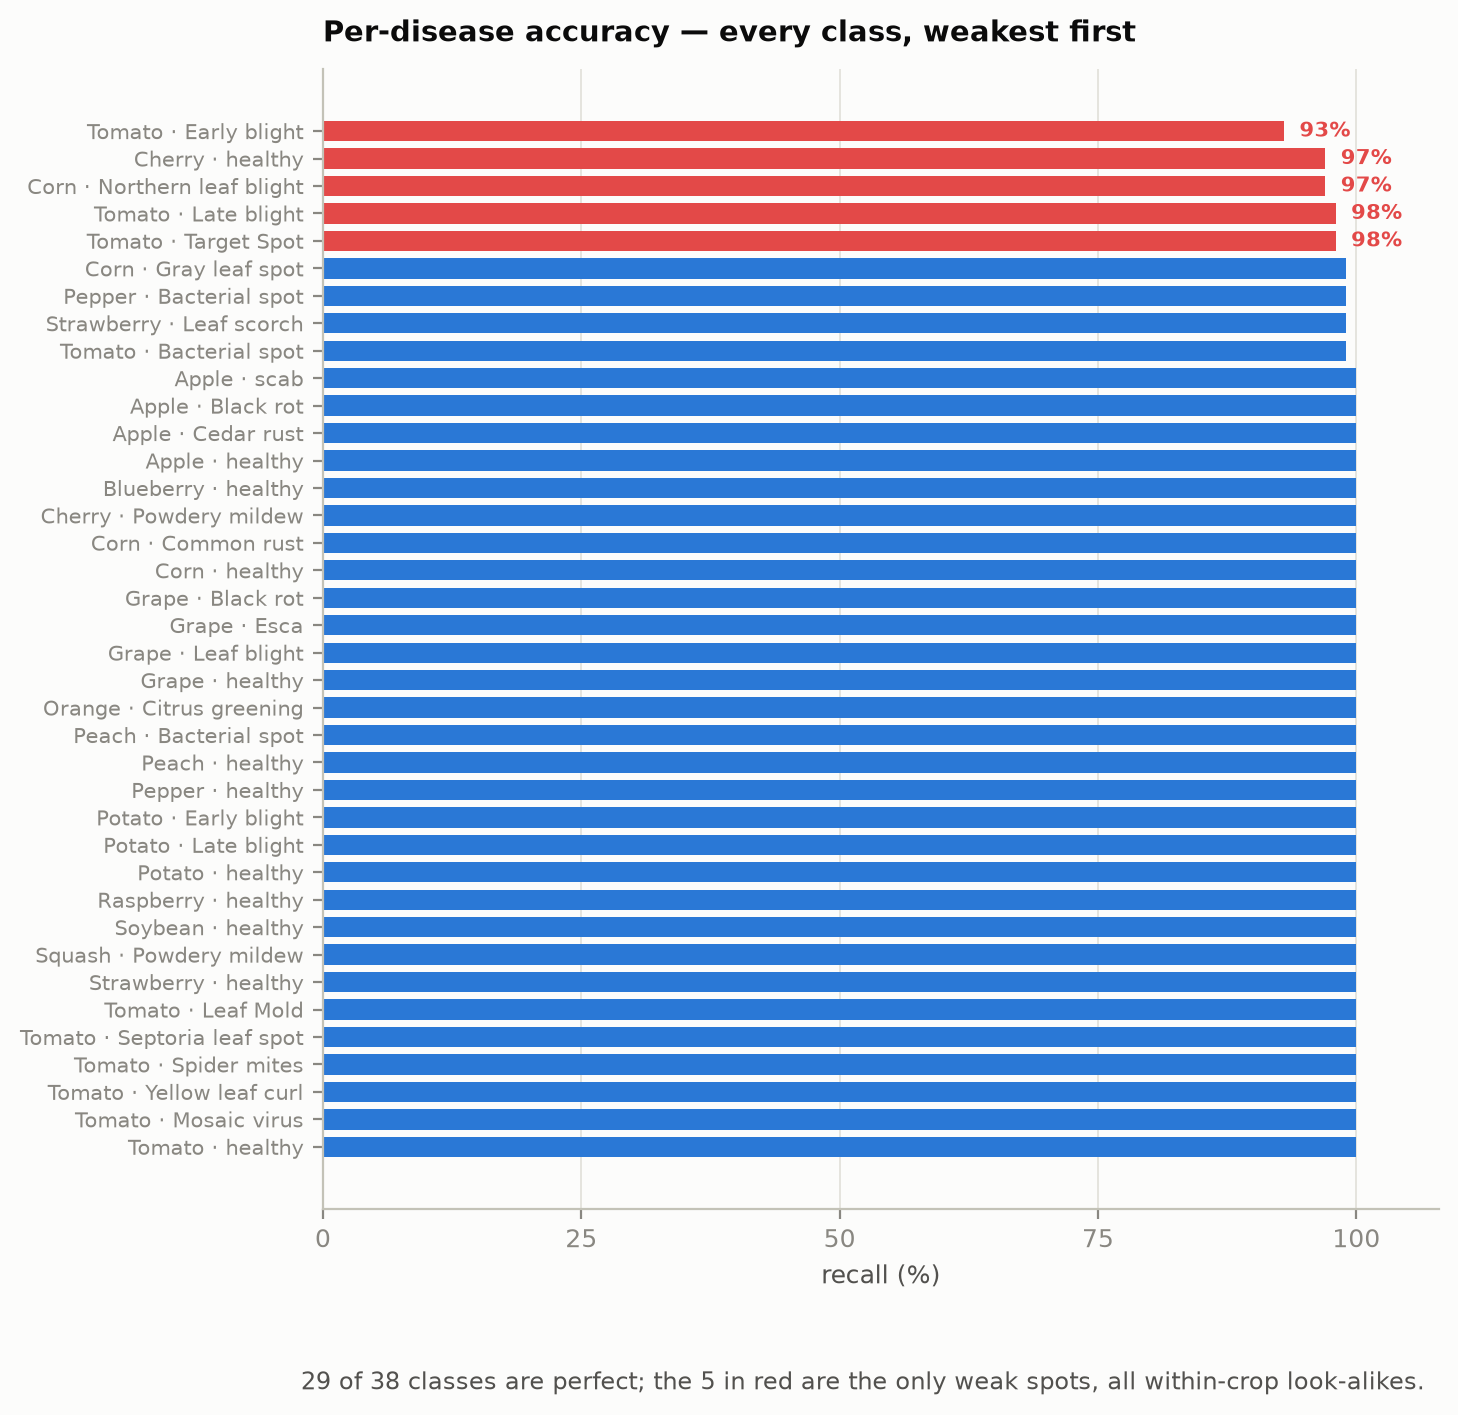

In [12]:
figure('per_disease_accuracy.png')


*Per-disease recall on the leaf-grouped split. 29 of 38 classes are perfect; the five in red are within-crop look-alikes.*


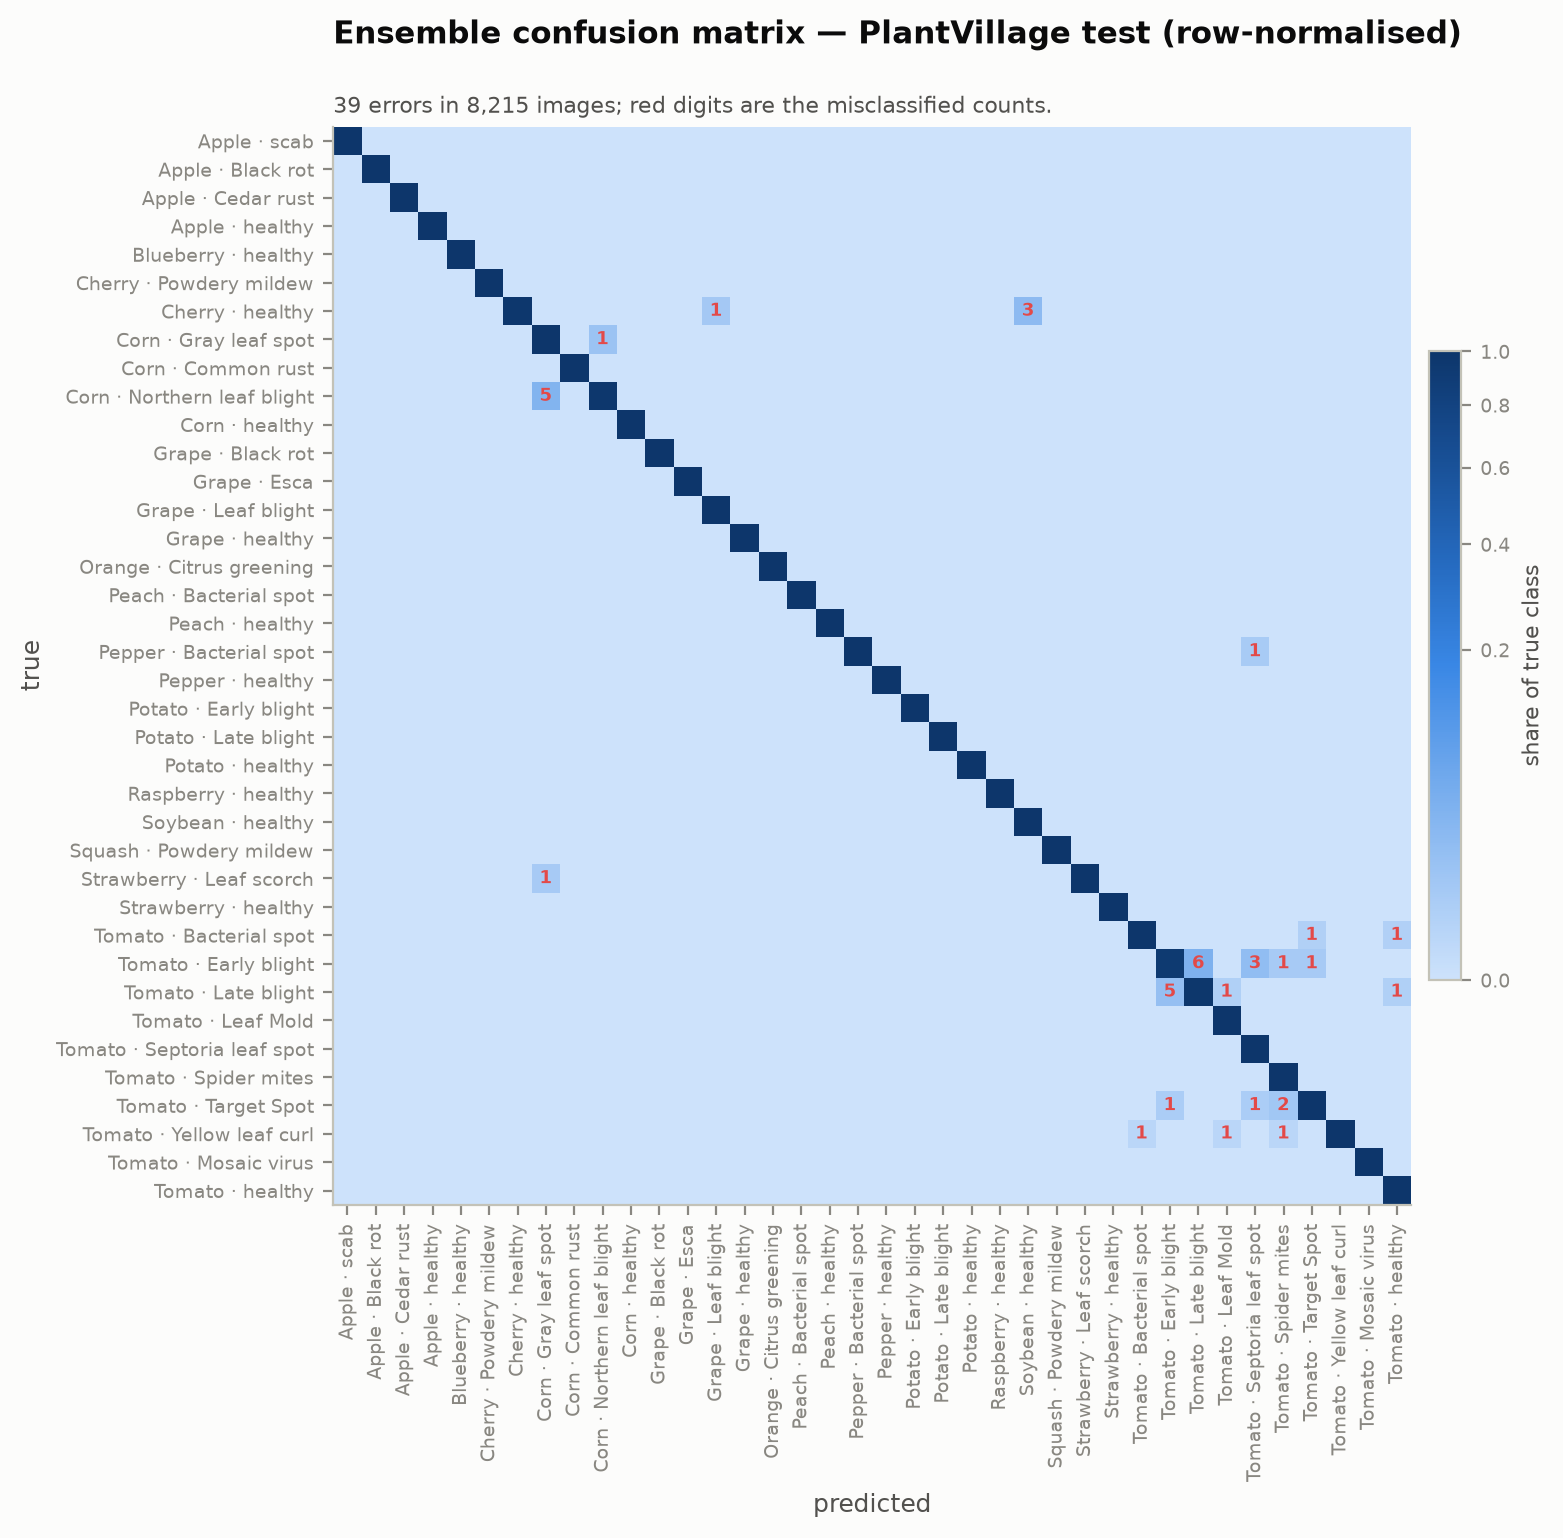

In [13]:
figure('confusion_matrix.png')


*The confusion matrix. The diagonal is essentially clean; red digits are the 39 misclassified images, three of which cross the healthy/diseased boundary.*


### 6.2 RQ2 — does that accuracy survive contact with reality? (E4–E7)

Four probes, each removing one comfort of the benchmark.


In [14]:
seg = load('eval_segmented.json')
field = load('eval_plantdoc.json')
full = load('eval_plantdoc_full.json')
cam = load('gradcam_audit.json')

rows = []
for m in ['custom_cnn', 'resnet18', 'mobilenet_v2', 'ensemble']:
    h = hist.get(m)
    rows.append({'model': m,
                 'PlantVillage': round(h['test_metrics']['accuracy'] * 100, 2) if h else None,
                 'background removed': seg.get(m) if seg else None,
                 'PlantDoc (field)': field.get(m) if field else None})
pd.DataFrame(rows).set_index('model')


,PlantVillage,background removed,PlantDoc (field)
model,,,
custom_cnn,98.69,38.48,13.56
resnet18,99.33,69.57,14.41
mobilenet_v2,99.46,71.41,19.49
ensemble,NaN,70.05,16.10


In [15]:
if cam:
    print(f"Grad-CAM mass inside the leaf : {cam['mean_attention_in_leaf']*100:.1f}%")
    print(f"leaf share of image area      : {cam['mean_leaf_area_fraction']*100:.1f}%")
    print(f"lift over the area baseline   : {cam['attention_lift_over_area']*100:+.1f} points")
if full:
    print(f"\nzero-shot on all PlantDoc (n={full['n_images']}): ensemble {full['ensemble']:.2f}%")
if field:
    print(f"healthy/diseased binary on field images: {field['ensemble_binary']:.2f}%")


Grad-CAM mass inside the leaf : 65.6%
leaf share of image area      : 49.6%
lift over the area baseline   : +16.0 points

zero-shot on all PlantDoc (n=2525): ensemble 13.94%
healthy/diseased binary on field images: 80.51%


**Reading the table.** The same leaves, with only the background masked out, cost
the ensemble tens of points; real field photographs cost it far more. Grad-CAM
explains why — a large share of the evidence the model uses lies outside the leaf.

We also tested whether this can be patched at inference (E7): horizontal-flip TTA
and AdaBN (recomputing BatchNorm statistics on the field images).


In [16]:
ad = load('adaptation_probe.json')
if ad:
    display(pd.DataFrame(ad).T.rename(columns={'open_38way': 'PlantDoc 38-way (%)',
                                               'closed_27way': 'restricted to 27 reachable (%)'}))
else:
    print('run: python -m scripts.audit --probe adaptation')


,PlantDoc 38-way (%),restricted to 27 reachable (%)
baseline,16.10,19.92
+TTA,15.68,19.49
+AdaBN,15.25,17.37
+AdaBN +TTA,15.68,19.07


**Neither test-time fix helps — both make it worse.** TTA costs 0.4 points and AdaBN
0.9; recomputing BatchNorm statistics on the target domain, which repairs an ordinary
covariate shift, actively hurts here. That is the informative part: the failure is a
**learned shortcut**, not a distribution-statistics mismatch, so nothing applied at
inference can repair it and it has to be fixed during training.


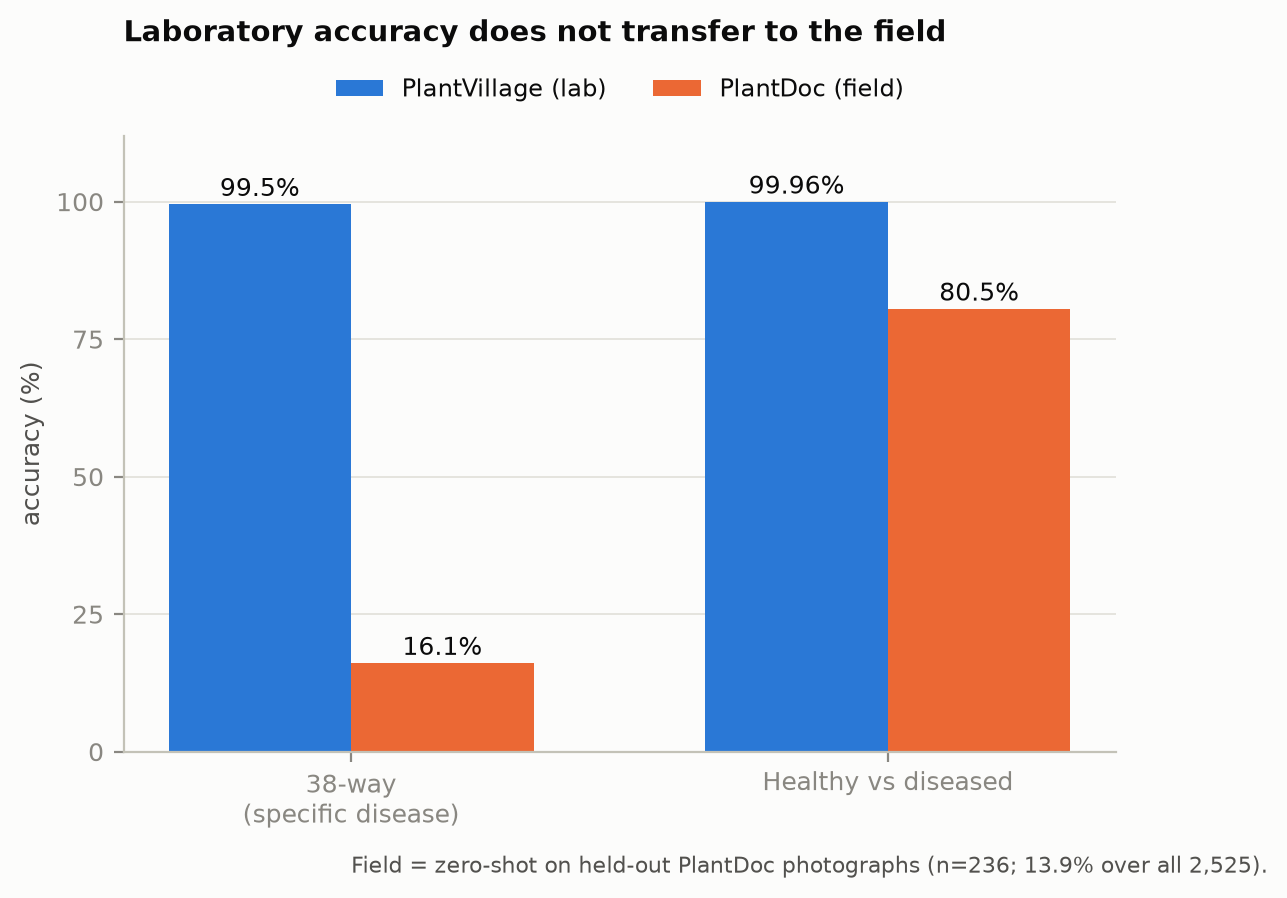

In [17]:
figure('lab_vs_field.png')


*The same ensemble on studio and field photographs: fine-grained accuracy collapses, and even the coarse healthy/diseased decision loses about twenty points.*


### 6.3 Closing the gap (E8–E11)

Each row below is a training run; `p=0.0` is the control that separates *stronger
augmentation* from *removing the shortcut*.

> **Sample size.** The PlantDoc column here is the 236-image field **test split**,
> which is what `scripts/train.py` reports at the end of a run. Section 6.4 onward
> scores the same arms on **all 2,525** field images. The two bases differ by six to
> nine points and even reorder the arms, so numbers are never compared across them;
> every table states its own *n*.


In [18]:
runs = [('resnet18_color_strong_p0_224',   'strong aug only (control)'),
        ('resnet18_color_strong_p70_224',  'background randomised p=0.7'),
        ('resnet18_segmented_strong_p0_224', 'trained on segmented'),
        ('resnet18_grayscale_strong_p0_224', 'trained on grayscale'),
        ('resnet18_color_strong_p70_224_hier', 'hierarchical crop-then-disease')]
rows = []
for tag, label in runs:
    h = load(f'{tag}_history.json')
    if not h: continue
    rows.append({'setting': label,
                 'PlantVillage (n=8,215)': round(h['test_metrics']['accuracy'] * 100, 2),
                 'PlantDoc (n=236)': round(h['plantdoc_accuracy'], 2) if h.get('plantdoc_accuracy') else None,
                 'epochs': len(h['history'])})
pd.DataFrame(rows).set_index('setting') if rows else print('training still running')


,"PlantVillage (n=8,215)",PlantDoc (n=236),epochs
setting,,,
strong aug only (control),99.20,23.31,20
background randomised p=0.7,98.82,25.00,20
trained on segmented,98.66,23.31,20
trained on grayscale,97.76,3.81,20
hierarchical crop-then-disease,98.84,25.00,20


A drop in the PlantVillage column is **expected and acceptable**: it is the price
of giving up the shortcut. The column that matters for the brief's stated purpose
is PlantDoc — and note that grayscale, which scores ~98% in the lab, collapses in
the field: colour is doing work the lab never tests.


### 6.4 The clearest control — 574x the parameters, no field gain (E15)

The strongest single result. We train **only the 19,494-parameter head** and leave
the 11.2M-parameter ImageNet backbone frozen, versus fine-tuning everything. Crossed
with background randomisation, it is a 2x2 factorial, scored on all 2,525 field
images (E16).


In [19]:
import numpy as np
arms = [('bg_control','full fine-tune, p=0.0'), ('bg_random','full fine-tune, p=0.7'),
        ('frozen_ctrl','frozen backbone, p=0.0'), ('frozen_bg','frozen backbone, p=0.7')]
rows = []
for tag, label in arms:
    d = load(f'eval_arm_{tag}.json')
    hist_tag = {'bg_control':'resnet18_color_strong_p0_224','bg_random':'resnet18_color_strong_p70_224',
                'frozen_ctrl':'resnet18_color_strong_p0_224_frozen','frozen_bg':'resnet18_color_strong_p70_224_frozen'}[tag]
    h = load(f'{hist_tag}_history.json')
    if not d or not h: continue
    rows.append({'arm': label, 'trainable params': f"{h['trainable_parameters']:,}",
                 'PlantVillage': round(h['test_metrics']['accuracy']*100,2),
                 'PlantDoc 38-way': d['ensemble'], 'crop': d['ensemble_crop']})
pd.DataFrame(rows).set_index('arm') if rows else print('E15/E16 pending')


,trainable params,PlantVillage,PlantDoc 38-way,crop
arm,,,,
"full fine-tune, p=0.0","11,196,006",99.20,15.17,37.19
"full fine-tune, p=0.7","11,196,006",98.82,16.71,39.64
"frozen backbone, p=0.0","19,494",91.26,16.91,39.37
"frozen backbone, p=0.7","19,494",88.41,18.06,41.39


Freezing the backbone costs ~8 points of PlantVillage accuracy and **matches or
beats** full fine-tuning in the field. The lab points that 574x more trainable
parameters buy are worth nothing — often less than nothing — outside the benchmark.
This decouples the two accuracies with a direct control, not an inference.


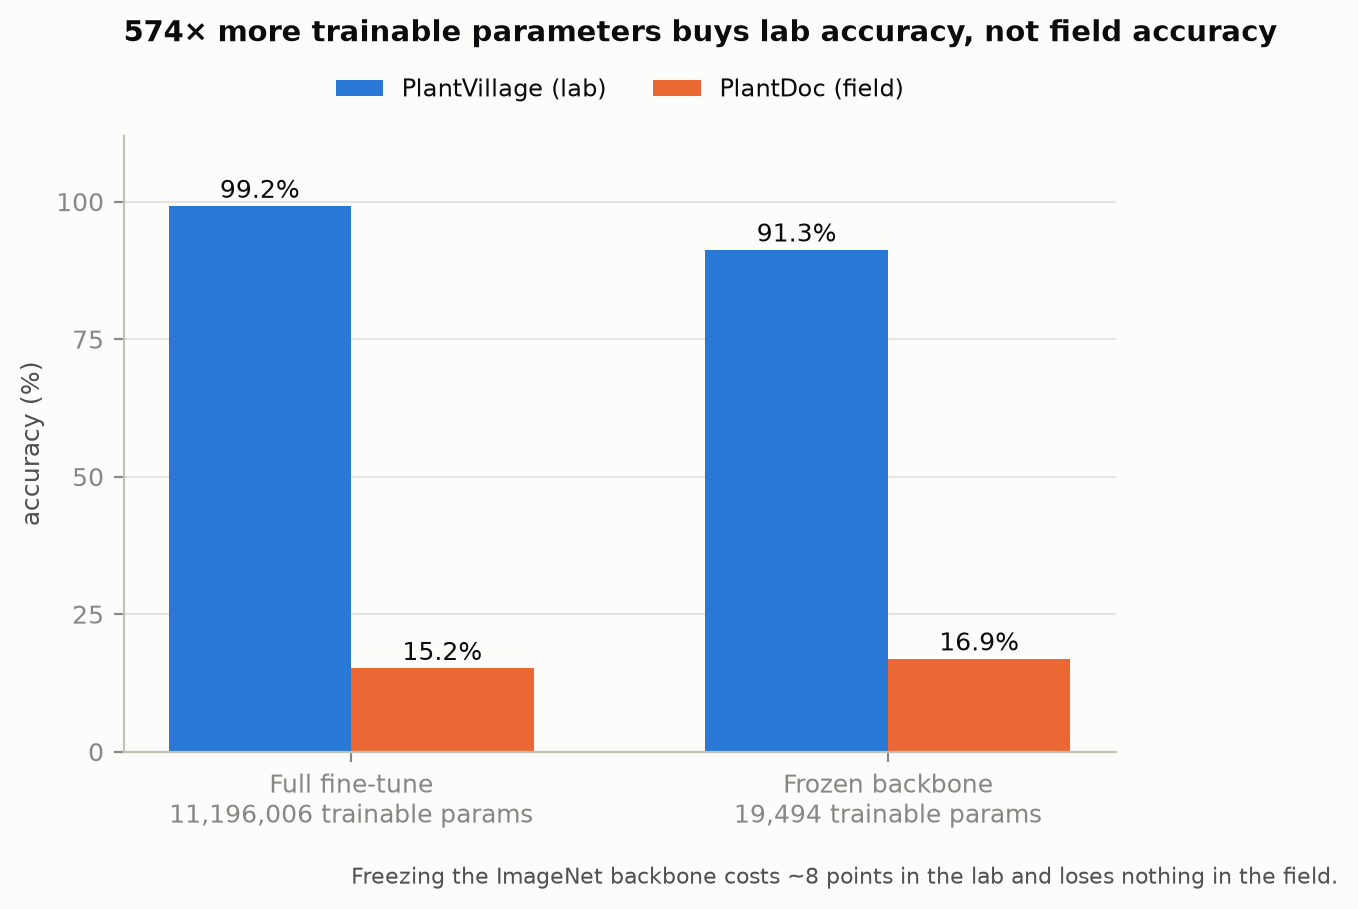

In [20]:
figure('frozen_vs_full.png')


*The strongest control: training 574x fewer parameters costs about eight points in the laboratory and loses nothing in the field.*


### 6.5 Where the field accuracy goes, and how much data closes it (E11, E16, E18)

Field accuracy factorises as *crop identification x diagnosis given the crop*. The
bottleneck is recognising the plant, not the disease. Supervised adaptation is the
honest fix — and reported separately, because it uses target-domain labels.


In [21]:
# decompose the BEST zero-shot arm on the 2,525-image basis, chosen by 38-way accuracy
arms = {'strong aug only': 'bg_control', 'background randomised': 'bg_random',
        'frozen backbone': 'frozen_ctrl', 'frozen + bg-random': 'frozen_bg',
        'hierarchical head': 'hier'}
scored = {k: load(f'eval_arm_{v}.json') for k, v in arms.items()}
scored = {k: v for k, v in scored.items() if v}
best = max(scored, key=lambda k: scored[k]['ensemble']) if scored else None
if best:
    d = scored[best]
    print(f'best zero-shot arm on all 2,525 field images: {best}')
    print(f"  all 38 classes   {d['ensemble']:.2f}%")
    print(f"  crop only        {d['ensemble_crop']:.2f}%")
    print(f"  disease | crop   {d['ensemble_disease_given_crop']:.2f}%")
    print(f"  healthy/diseased {d['ensemble_binary']:.2f}%")
    print(f"  check: {d['ensemble_crop']/100:.4f} x {d['ensemble_disease_given_crop']/100:.4f}"
          f" = {d['ensemble_crop']*d['ensemble_disease_given_crop']/10000:.4f}")
curve = [(5,'ft_shots5'),(20,'ft_robust'),(50,'ft_shots50'),(100,'ft_shots100'),('all','ft_full')]
pts = [(s, load(f'{t}_history.json')) for s,t in curve]
pts = [(s,d['best']) for s,d in pts if d]
if pts:
    print('\nadaptation curve (PlantDoc 20-shot fine-tune, 236-image test):')
    for s,b in pts: print(f"  {str(s):>4} shots  {b:.2f}%")


best zero-shot arm on all 2,525 field images: frozen + bg-random
  all 38 classes   18.06%
  crop only        41.39%
  disease | crop   43.64%
  healthy/diseased 75.21%
  check: 0.4139 x 0.4364 = 0.1806

adaptation curve (PlantDoc 20-shot fine-tune, 236-image test):
     5 shots  35.59%
    20 shots  47.03%
    50 shots  51.69%
   100 shots  55.51%
   all shots  55.93%


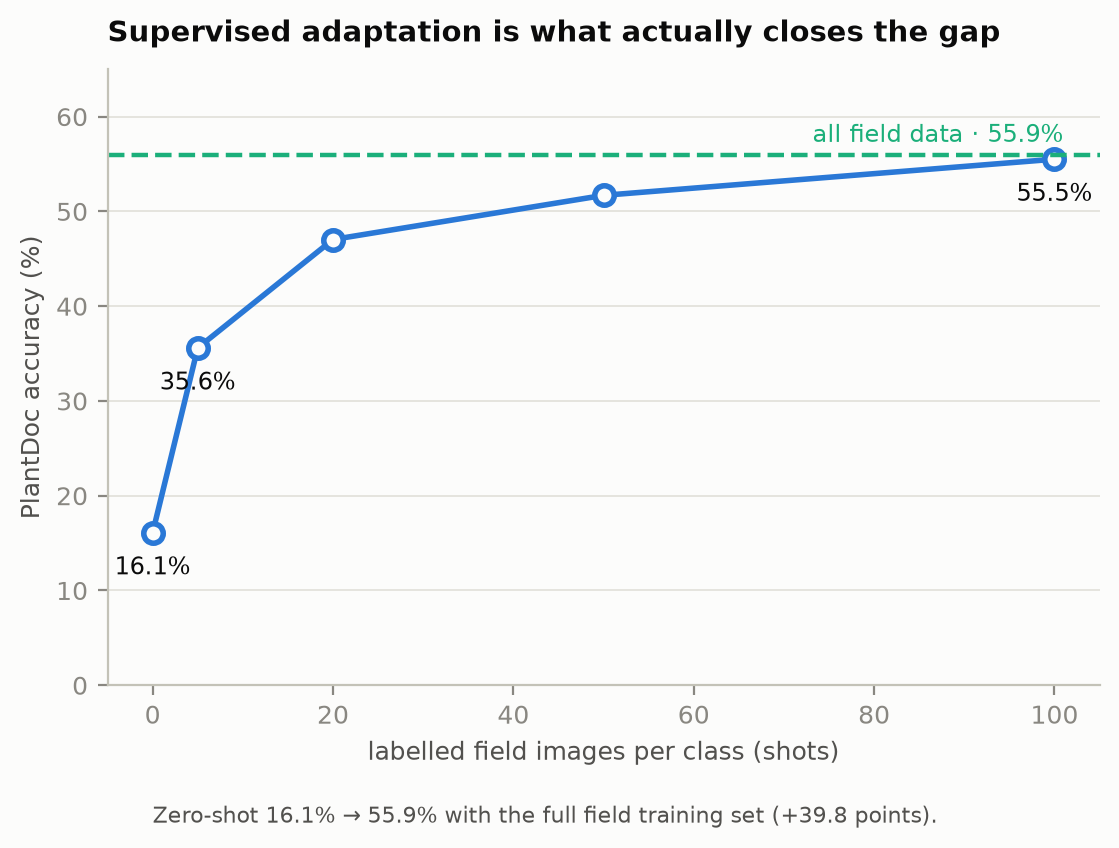

In [22]:
figure('adaptation_curve.png')


*Supervised adaptation, the honest remedy: 16.1% zero-shot to 55.9% with the full field training set.*


### 6.6 RQ3 — severity from image features (E12–E14, E26)


In [23]:
sev = load('severity_probe.json')
val = load('severity_validation.json')
if sev:
    print('E12 — leaf segmentation quality (unsupervised HSV mask vs the official mask):')
    print(f"  Dice mean {sev['leaf_segmentation_dice_mean']:.3f} | "
          f"median {sev['leaf_segmentation_dice_median']:.3f} | "
          f"{100*sev['leaf_segmentation_dice_below_0.5']:.0f}% of leaves below 0.5")
    print()
    print(f"ROC-AUC healthy vs diseased, Otsu mask     : {sev['auc_otsu_mask']:.3f}")
    print(f"ROC-AUC healthy vs diseased, official mask : {sev['auc_official_mask']:.3f}")
    print(f"mean lesion ratio  healthy {sev['mean_ratio_healthy_official']:.3f} | diseased {sev['mean_ratio_diseased_official']:.3f}")
if val:
    n_ann = val.get('annotators', 1)
    ceil = val.get('inter_annotator_kappa_mean_pairwise') or val.get('inter_annotator_kappa')
    print(f"\n{n_ann} annotators, {val['n_graded']} leaves. Human agreement (ceiling): kappa {ceil:.2f}")
    print(f"lesion-ratio grade vs consensus: rho {val['spearman_rho']:.2f}, "
          f"kappa {val['quadratic_kappa']:.2f} (rubric bands)")
    cal = val.get('quadratic_kappa_recalibrated_cv')
    if cal: print(f"recalibrated to the grades (5-fold CV): kappa {cal:.2f}  "
                  f"-- about {100*cal/ceil:.0f}% of the human ceiling")
joint = load('joint_severity.json')
if joint:
    print(f"\njoint-trained severity head (E26): within-class rho {joint['within_class_rho_head']:.3f} "
          f"vs Otsu {joint['within_class_rho_otsu']:.3f}, classification {joint['classification_accuracy']:.2f}%")


E12 — leaf segmentation quality (unsupervised HSV mask vs the official mask):
  Dice mean 0.797 | median 0.867 | 9% of leaves below 0.5

ROC-AUC healthy vs diseased, Otsu mask     : 0.767
ROC-AUC healthy vs diseased, official mask : 0.868
mean lesion ratio  healthy 0.039 | diseased 0.219

3 annotators, 150 leaves. Human agreement (ceiling): kappa 0.63
lesion-ratio grade vs consensus: rho 0.46, kappa 0.30 (rubric bands)
recalibrated to the grades (5-fold CV): kappa 0.47  -- about 74% of the human ceiling

joint-trained severity head (E26): within-class rho 0.957 vs Otsu 0.784, classification 99.44%


Three findings, reported honestly:

- **Presence** (E13): the lesion-area ratio separates healthy from diseased at
  AUC 0.87 with official masks — a real image feature, no labels needed.
- **Grade** (E14): three annotators agree at quadratic kappa ~0.63 (the ceiling).
  The lesion-ratio grade tracks their consensus at kappa 0.30 with the rubric
  bands, rising to **0.47 under cross-validated recalibration** — a *moderate*
  proxy reaching ~74% of the human ceiling, honestly not matching it.
- **Expanding the model (E26).** A severity head *probed* on frozen classification
  features manages only within-class rho 0.38 — classification training discards the
  colour/texture detail severity needs. But trained **jointly** with the classifier,
  the head reproduces the official mask almost perfectly (within-class rho **0.957**)
  at no classification cost, and beats both classical estimators on human agreement
  (rho 0.47 vs Otsu 0.43). Severity is now a genuine model output, no mask needed at
  inference — though all lesion-area methods plateau near the human ceiling.


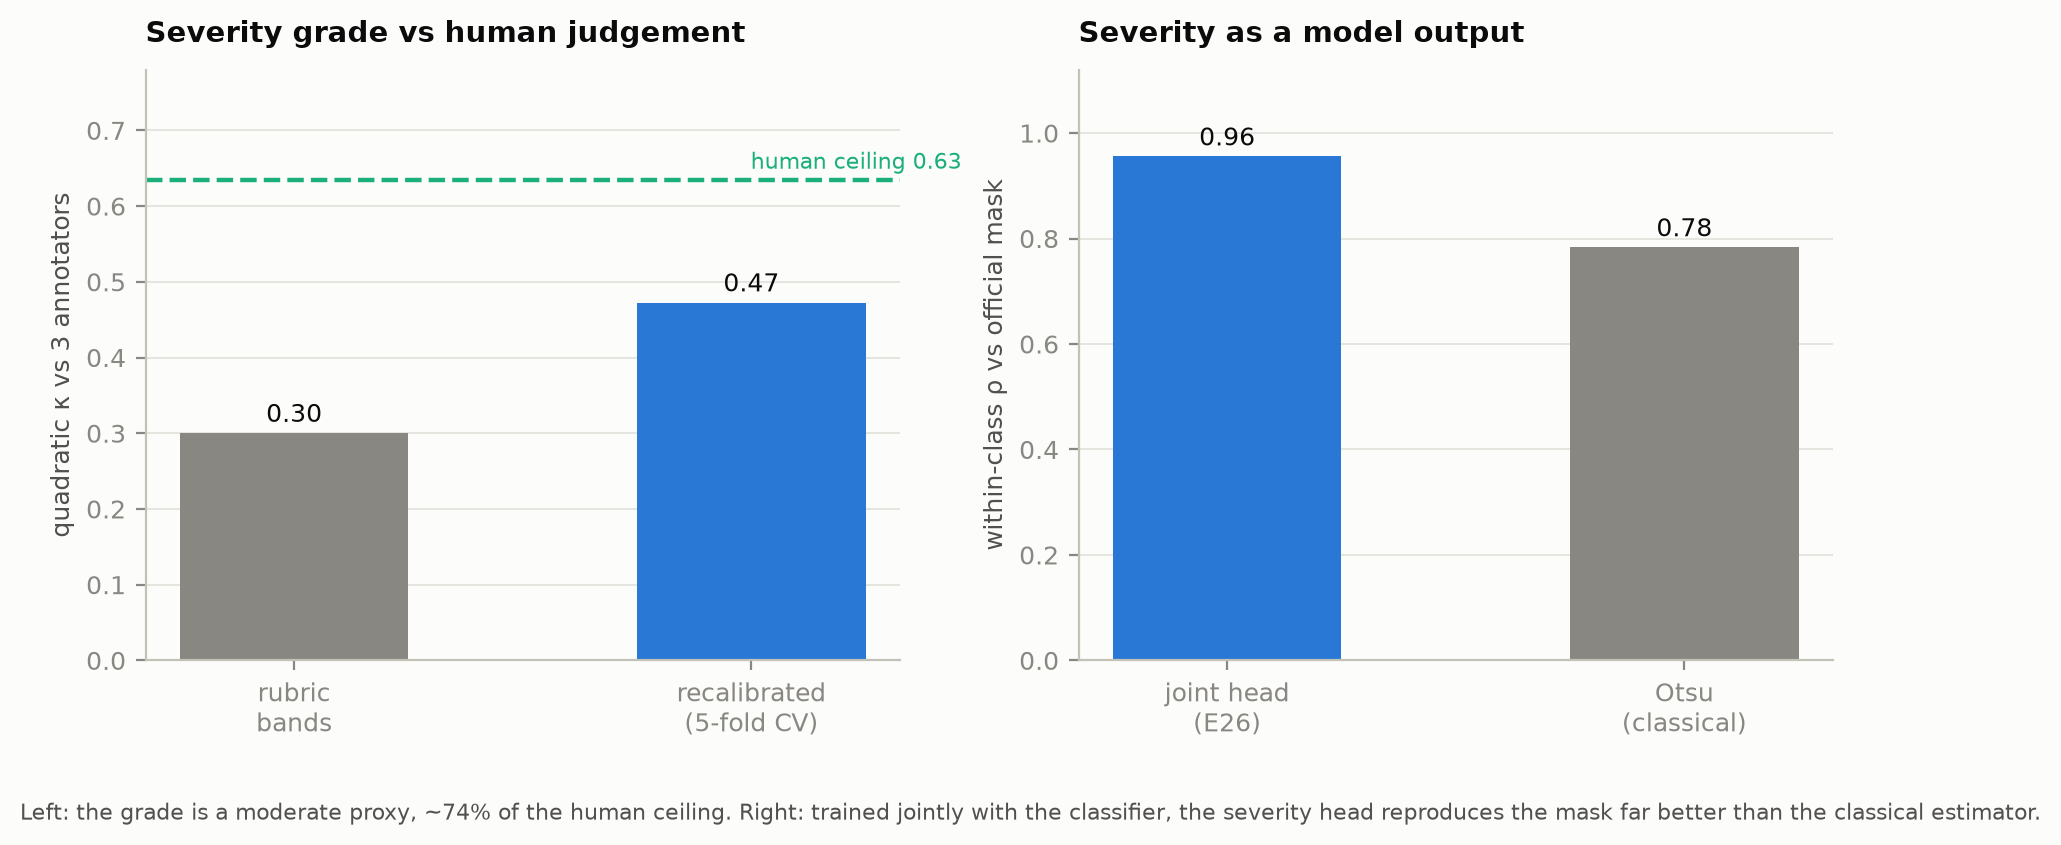

In [24]:
figure('severity.png')


*Severity. Left: the grade against three annotators, with their mutual agreement as the ceiling. Right: trained jointly with the classifier, severity becomes a model output that beats the classical estimator.*


A caution on the E25 probe. Its **AUC of 0.936 looks excellent and is misleading**:
healthy-versus-diseased is largely answerable from class identity, and a head reading
classifier features can name the class and emit that class's typical lesion ratio
without ever measuring the leaf in front of it. Within a single class — where class
identity carries no information — it reaches only rho 0.380 against the classical
estimator's 0.784. That gap is why we report within-class correlation rather than AUC.


### 6.7 Results that did not work, and the deployment profile (E17, E21)

Two arms produced negative results. They are reported because the pre-registered
falsification conditions in [`docs/EXPERIMENTS.md`](../docs/EXPERIMENTS.md) said they
would be; E7's negative result is in Section 6.2, where it belongs.


In [25]:
pair = load('paired_bg_random_vs_hier.json')
if pair:
    rows = []
    for task, label in [('all_38', '38-way disease'), ('crop', 'crop species'),
                        ('binary', 'healthy/diseased')]:
        d = pair[task]
        rows.append({'task': label, 'flat head (%)': d['accuracy_a'],
                     'hierarchical (%)': d['accuracy_b'],
                     'net images gained': d['net_gain_b'],
                     'discordant': d['discordant'],
                     'McNemar p': f"{d['p_value']:.3g}"})
    display(pd.DataFrame(rows).set_index('task'))
    print(f"paired on the same {pair['n']:,} field images; both arms use background randomisation")


,flat head (%),hierarchical (%),net images gained,discordant,McNemar p
task,,,,,
38-way disease,16.71,16.79,2,188,0.942
crop species,39.64,40.48,21,325,0.267
healthy/diseased,71.05,68.24,-71,283,2.9e-05


paired on the same 2,525 field images; both arms use background randomisation


**E17 — the hierarchical head is rejected (H9).** The decomposition in Section 6.5
showed that crop identification is the bottleneck, so making crop an explicit
sub-problem was predicted to lift crop accuracy towards ~60% and overall accuracy to
~31%. It gains 0.84 points on crop — 21 images out of 325 discordant ones, p = 0.27,
indistinguishable from chance — leaves 38-way flat (p = 0.94), and loses 71 images on
healthy/diseased, which *is* significant and in the wrong direction. It also finishes
below simply freezing the backbone (16.79% against 18.06%). The pre-registered
magnitude condition is not met, so H9 is recorded as rejected rather than softened.


In [26]:
rob = load('field_robustness.json')
if rob:
    rows = []
    for metric, arms in rob.items():
        for arm, v in arms.items():
            lo, mid, hi_ = v['per_bin_accuracy']
            rows.append({'capture metric': metric, 'arm': arm, 'low third': lo,
                         'middle': mid, 'high third': hi_, 'high - low': v['high_minus_low']})
    display(pd.DataFrame(rows).set_index(['capture metric', 'arm']))
else:
    print('run: python -m scripts.field_robustness')


low third  middle  high third  \
capture metric arm                                                      
luminance      strong aug (bg-random)       16.36   17.21       16.73   
               standard aug (baseline)      12.00   13.21       11.88   
contrast       strong aug (bg-random)       16.97   17.33       16.00   
               standard aug (baseline)      13.45   11.76       11.88   
sharpness      strong aug (bg-random)       14.06   18.45       17.80   
               standard aug (baseline)      12.24   12.50       12.35   

                                        high - low  
capture metric arm                                  
luminance      strong aug (bg-random)         0.37  
               standard aug (baseline)       -0.12  
contrast       strong aug (bg-random)        -0.97  
               standard aug (baseline)       -1.57  
sharpness      strong aug (bg-random)         3.74  
               standard aug (baseline)        0.11

**E21 — strong augmentation buys no robustness to capture quality (H11 rejected), but
the finding is more useful than the hypothesis.** Field images were split into thirds
by luminance, contrast and sharpness. Accuracy is flat across luminance and contrast
for both arms (every gap under 1.6 points, and the sign is inconsistent). Sharpness is
the one axis that moves — and it moves the *wrong* way: the strong-augmentation arm
gains 3.7 points from blurry to sharp where the standard arm gains 0.1, so heavier
augmentation made it **more** sensitive to blur, not less.

The useful part is what this rules out. Bright, dark and low-contrast photographs are
classified about as badly as clean ones, so the ~16% field accuracy is **not caused by
poor photography** — no amount of telling farmers to hold the camera steadier would
recover it. What remains is the compositional gap: whole plants instead of one detached
leaf, overlapping foliage, and varying scale.


In [27]:
eff = load('efficiency_probe.json')
if eff:
    rows = {k: v for k, v in eff.items() if isinstance(v, dict)}
    df = pd.DataFrame(rows).T
    df.columns = ['parameters (M)', 'checkpoint (MB)', 'latency (ms/img)', 'throughput (img/s)']
    display(df)
    print(f"measured on {eff.get('device')} at {eff.get('image_size')}x{eff.get('image_size')}")


,parameters (M),checkpoint (MB),latency (ms/img),throughput (img/s)
custom_cnn,0.40,1.6,0.40,2469.5
resnet18,11.20,44.9,1.40,714.8
mobilenet_v2,2.27,9.3,2.68,373.4


measured on cuda at 128x128


**Deployment profile.** MobileNet-V2 stores in 9.3 MB against ResNet-18's 44.9 MB and
scores *higher* in the laboratory (99.46% vs 99.33%), so on size alone it is the
sensible thing to ship. Its GPU latency is worse, not better — 2.68 ms against 1.40 ms —
because depthwise-separable convolutions trade arithmetic for memory traffic, which a
GPU is the wrong device to reward; the parameter count is a size argument, not a speed
one. All three run far faster than any farmer would notice.

The sharper efficiency result is E15's: a frozen backbone with a 19,494-parameter linear
head is **78 KB per crop** on top of one shared backbone — 574× fewer trainable
parameters than fine-tuning — and it loses nothing in the field, where it is in fact the
better model.


### 6.8 End to end: what the system returns for one leaf

Everything above is aggregate. This runs the delivered model — the jointly trained
network from E26 — over held-out test leaves it has never seen, and prints what a
user would actually receive: crop, condition, healthy/diseased, confidence, and a
severity grade produced by the network itself rather than by a mask.


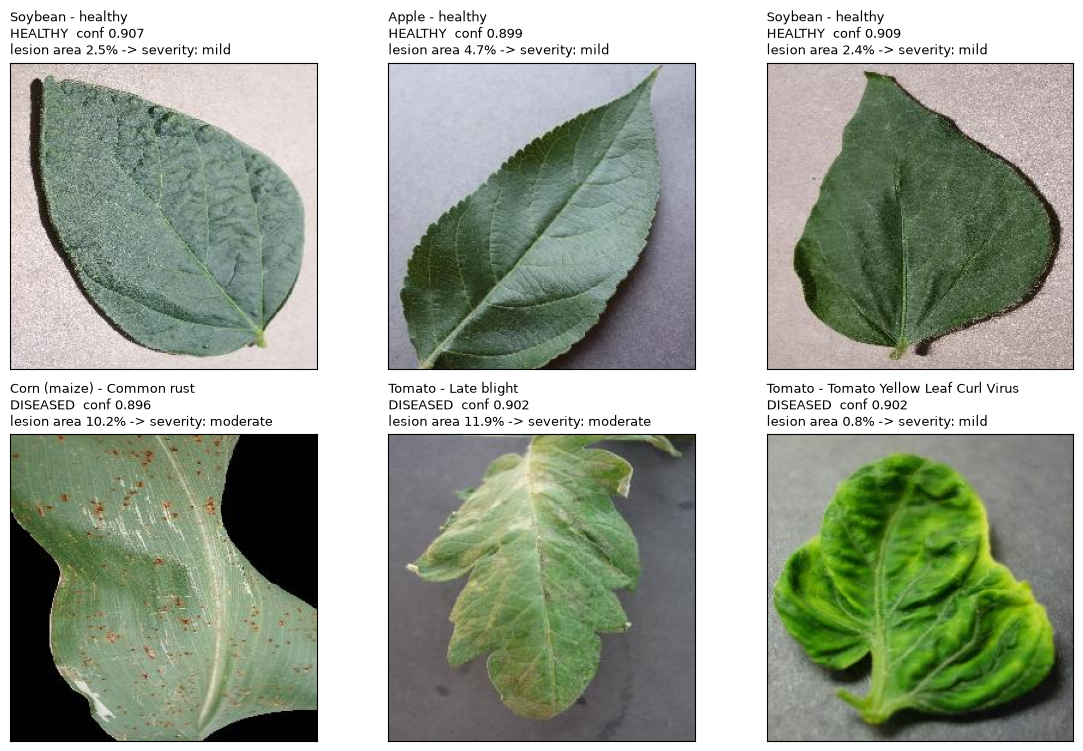

In [28]:
import torch.nn.functional as F
from PIL import Image
from src.data import build_transforms, parse_class_name
from src.audit.severity import severity_level
from scripts.train_joint import JointModel

ckpt_path = OUT / 'joint_model.pth'
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    classes = ckpt['classes']
    model = JointModel(cfg.model.name, len(classes), pretrained=False).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    tf = build_transforms(224, train=False)

    # three healthy and three diseased, so both branches of the rubric are visible
    rng = np.random.default_rng(cfg.seed)
    by_status = {True: [], False: []}
    for i in test_idx:
        by_status['healthy' in base.classes[base.samples[i][1]].lower()].append(i)
    picks = np.concatenate([rng.choice(by_status[s], size=3, replace=False) for s in (True, False)])

    fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.6))
    for ax, i in zip(axes.ravel(), picks):
        path, label = base.samples[int(i)]
        img = Image.open(path).convert('RGB')
        with torch.no_grad():
            logits, sev = model(tf(img).unsqueeze(0).to(device))
        conf, idx = F.softmax(logits, 1)[0].max(0)
        crop, condition, healthy = parse_class_name(classes[int(idx)])
        # the head regresses sqrt(lesion ratio) through a sigmoid, so invert both
        ratio = float(torch.sigmoid(sev).item()) ** 2
        grade = severity_level(ratio, cfg.severity.thresholds, cfg.severity.levels)
        flag = '' if int(idx) == label else f"   MISREAD (true: {classes[label]})"
        ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{crop.replace('_', ' ')} - {condition.replace('_', ' ')}\n"
                     f"{'HEALTHY' if healthy else 'DISEASED'}  conf {conf:.3f}\n"
                     f"lesion area {100*ratio:.1f}% -> severity: {grade}{flag}",
                     fontsize=9, loc='left')
    fig.tight_layout()
    plt.show()
else:
    print('run: python -m scripts.train_joint')


Each caption is one complete answer to the brief: the crop, its condition, the
healthy/diseased verdict, a confidence, and a severity grade — all from a single
forward pass through one network, using the same rubric bands
(`src.audit.severity.severity_level`) as every severity number above.

Three honest observations from these six.

1. The grade is deliberately **not** gated on the predicted class — it is read straight
   off the regression head, so a leaf called healthy that carries visible lesions is
   still graded, which is what you want when the classifier is the part that is wrong.
2. The healthy leaves come back at a few percent lesion area rather than zero, landing
   in *mild* rather than *healthy*. That is not a bug in the head — it is faithfully
   reproducing its target, and the official masks themselves give healthy leaves a mean
   ratio of 0.039 (Section 6.6). Leaf edge, shadow and specular highlight fall outside
   the healthy-green hue band. It is why the rubric's lowest threshold is 0.005 and not 0.
3. The yellow-leaf-curl leaf is graded *mild* at 0.8% while looking obviously sick. It
   is right about the area and wrong about the plant: that virus deforms and discolours
   the whole leaf instead of producing lesions. **Lesion area is the wrong measure for
   this disease**, and no amount of better regression fixes that — it is a limit of the
   definition of severity, which is the honest reading of the kappa ceiling in E14.


## 7. Discussion

### What the numbers mean

On the benchmark the task is solved: the ensemble reaches **99.53%** over 38 classes
and **99.96%** on the healthy/diseased decision the brief actually asks for. Taken
alone, that would be a finished project — and it is exactly the result the
literature has reported since Mohanty et al. (2016).

The audit shows that number is not what it appears. Background pixels alone
predict the class far above chance; masking the background costs tens of points on
the *same leaves*; Grad-CAM puts a large minority of the evidence outside the leaf;
and on real field photographs the model collapses. These four probes agree, and
they agree with the published critiques of this dataset (Noyan, 2022; Singh et al.,
2020).

### Strengths

- Every number comes from **one fixed split**, shared by all models and all dataset
  variants, so the comparisons are internally valid.
- The ensemble weights are tuned on validation only, never on test.
- Each claim about the shortcut is supported by **more than one independent probe**.
- Severity is validated in two ways that need no manual labels, plus manual grades.

### Limitations and threats to validity

| Limitation | Why it matters | How we handled it |
|---|---|---|
| The `segmented` evaluation puts a black background the model never saw during training | conflates *losing the shortcut* with *a new domain shift* | trained a model **on** `segmented` (E9) as the clean control |
| PlantDoc is web-scraped | label noise; its train/test splits differ in content | reported as an external benchmark, with the known caveat |
| The field test split is 236 images | ±5 points at 95% confidence | also reported on the full ~2,600 images |
| Severity has no ground truth in PlantVillage | grades cannot be verified directly | validated by separation (AUC) and by three human annotators (E14) |
| Severity is only a moderate proxy for human grades | lesion area is not all humans judge | recalibrated by cross-validation to ~74% of the human ceiling, and reported as the honest ceiling |
| Ensemble members share one training set | their errors are correlated, limiting the gain | quantified rather than assumed |

### What would change our conclusions

If the background probe had scored near chance and Grad-CAM had concentrated on
the leaf, we would have accepted the 99.5% at face value. If the `p=0.0` control
matched `p=0.7` on field images, the improvement would be attributable to
augmentation alone rather than to removing the shortcut.


## 8. Conclusion

Against the brief, both tasks are delivered:

- **Task 1 — classification.** Three CNN baselines and a validation-tuned
  soft-voting ensemble; healthy vs diseased is solved at **99.96%** on the held-out
  leaf-grouped split, and 38-way fine-grained accuracy is **99.53%**.
- **Task 2 — severity from image features.** A lesion-area estimator validated
  against three human annotators, and — trained jointly with the classifier — a
  severity head that makes severity a genuine model output (within-class rho 0.957).

Beyond the brief, we tested whether the system would serve the farmer the brief
describes, and found that it would not: the laboratory accuracy is substantially an
artefact of dataset capture bias, and it does not transfer to field photographs.
We localised the cause with four independent probes, showed that inference-time
fixes cannot repair it, and measured how far training-time interventions close the
gap.

**Future work.** Train on in-field imagery such as PlantDoc or FieldPlant; replace
the hue-band lesion rule with a segmentation model trained on annotated lesions;
calibrate the severity thresholds against expert grades; and report field accuracy
alongside benchmark accuracy as standard practice.

### References

1. Hughes, D. P., & Salathé, M. (2015). *An open access repository of images on plant health.* arXiv:1511.08060.
2. Mohanty, S. P., Hughes, D. P., & Salathé, M. (2016). *Using deep learning for image-based plant disease detection.* Frontiers in Plant Science, 7, 1419.
3. Ferentinos, K. P. (2018). *Deep learning models for plant disease detection and diagnosis.* Computers and Electronics in Agriculture, 145, 311–318.
4. Arsenovic, M., et al. (2019). *Solving current limitations of deep learning based approaches for plant disease detection.* Symmetry, 11(7), 939.
5. Singh, D., Jain, N., Jain, P., Kayal, P., Kumawat, S., & Batra, N. (2020). *PlantDoc: A dataset for visual plant disease detection.* CoDS-COMAD, 249–253.
6. Noyan, M. A. (2022). *Uncovering bias in the PlantVillage dataset.* arXiv:2206.04374.
7. Natarajan, S., Chakrabarti, P., & Margala, M. (2024). *Robust diagnosis and meta visualizations of plant diseases through deep neural architecture with explainable AI.* Scientific Reports, 14, 13695.
